<a href="https://colab.research.google.com/github/ishika-dattatray-date/python-basic-project/blob/main/Task_Submission_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving DOC-20260709-WA0004..csv to DOC-20260709-WA0004. (1).csv


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("DOC-20260709-WA0004..csv")

In [ ]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
print(df.shape)

(918, 12)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Q2

In [ ]:
# Check missing values
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [ ]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3

In [ ]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates()

# Print new shape
print("New Shape:", df.shape)

Duplicate Rows: 0
New Shape: (918, 12)


Q4

In [ ]:
# Count invalid values
cholesterol_zero = (df["Cholesterol"] == 0).sum()
restingbp_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0:", cholesterol_zero)
print("Rows with RestingBP = 0:", restingbp_zero)

Rows with Cholesterol = 0: 172
Rows with RestingBP = 0: 1


Q5

In [ ]:
# Statistical summary before cleaning
print("Before Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

# Calculate mean excluding zeros
chol_mean = df.loc[df["Cholesterol"] != 0, "Cholesterol"].mean()
bp_mean = df.loc[df["RestingBP"] != 0, "RestingBP"].mean()

# Replace 0 values with mean
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Round values to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

# Statistical summary after cleaning
print("\nAfter Cleaning:")
print(df[["Cholesterol", "RestingBP"]].describe())

Before Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    198.799564  132.396514
std     109.384145   18.514154
min       0.000000    0.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning:
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6

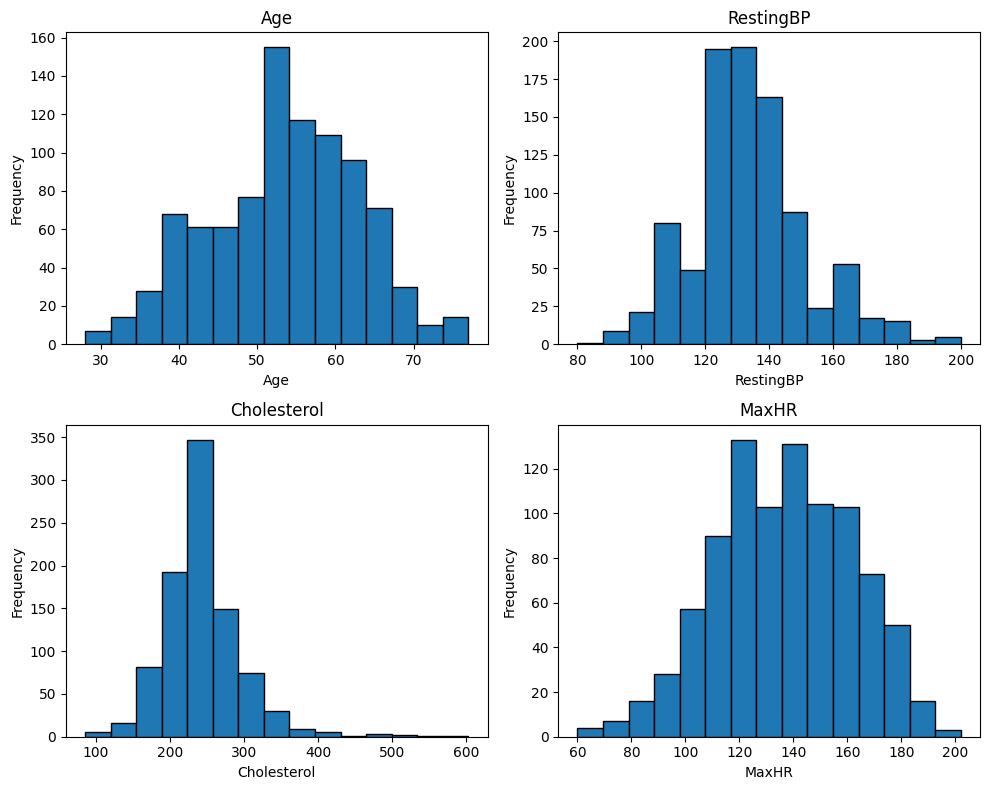

In [21]:
import matplotlib.pyplot as plt

# Function to plot histograms
def plot_histograms(data):
    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(10, 8))

    for i, col in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        plt.hist(data[col], bins=15, edgecolor="black")
        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Call the function
plot_histograms(df)

In [22]:
# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Print both
print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [23]:
# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df)

# Print shape
print("Shape of Encoded DataFrame:", df_encoded.shape)

# Display first 5 rows
df_encoded.head()


Shape of Encoded DataFrame: (918, 21)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,False,True,False,...,False,False,False,True,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,True,False,False,...,True,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,False,True,False,...,False,False,False,False,True,True,False,False,False,True
3,48,138.0,214.0,0,108,1.5,1,True,False,True,...,False,False,False,True,False,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,False,True,False,...,True,False,False,True,False,True,False,False,False,True


In [24]:
# Print final shape
print("Final Shape of Encoded DataFrame:")
print(df_encoded.shape)

# Print all column names
print("\nColumn Names:")
print(df_encoded.columns.tolist())

Final Shape of Encoded DataFrame:
(918, 21)

Column Names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [25]:
print("1. Invalid values found:")
print("- Cholesterol = 0")
print("- RestingBP = 0")
print("These values were replaced with the mean of non-zero values.\n")

print("2. Handling invalid values is important because zero is not a realistic value for Cholesterol or RestingBP and can reduce model accuracy.\n")

print("3. One-Hot Encoding converts categorical variables into numerical columns so that machine learning algorithms can process them.\n")

print("4. After cleaning and encoding, the dataset became suitable for machine learning and data analysis.")

1. Invalid values found:
- Cholesterol = 0
- RestingBP = 0
These values were replaced with the mean of non-zero values.

2. Handling invalid values is important because zero is not a realistic value for Cholesterol or RestingBP and can reduce model accuracy.

3. One-Hot Encoding converts categorical variables into numerical columns so that machine learning algorithms can process them.

4. After cleaning and encoding, the dataset became suitable for machine learning and data analysis.
